In [11]:
# Mount Google Drive and extract the ASCII text transcriptions
from google.colab import drive
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Connection Google Drive for dataset i downloaded from IAM Handwriting site (the second link in the PDF for task)
drive.mount('/content/drive')

# temporary folder in Colab to hold the extracted text
ascii_dir = '/content/iam_ascii'
os.makedirs(ascii_dir, exist_ok=True)

# Path to the ascii.tar file in Drive
tar_path = '/content/drive/MyDrive/CODSOFT_Task5/ascii.tar'

# Extract the text data instantly using a Linux bash command
print("Extracting text data...")
!tar -xf "{tar_path}" -C "{ascii_dir}"
print("Extraction complete! Ready to process the text.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting text data...
Extraction complete! Ready to process the text.


In [12]:
# Read the extracted words.txt file and build a massive text corpus for the RNN to learn from
words_file = os.path.join(ascii_dir, 'words.txt')
text_corpus = ""

print("Reading transcriptions and building the text corpus...")
with open(words_file, 'r') as file:
    for line in file:
        # Ignore comments and empty lines
        if line.startswith("#") or not line.strip():
            continue

        parts = line.strip().split()
        # The transcription is the last element in the line
        if parts[1] == "ok":  # Only use properly segmented words
            word = parts[-1]
            text_corpus += word + " "

# Clean up the text
text_corpus = text_corpus.lower()
text_corpus = text_corpus[:300000] # Use the first 300,000 characters for robust training

print(f"Corpus built successfully! Total characters to learn from: {len(text_corpus)}")

Reading transcriptions and building the text corpus...
Corpus built successfully! Total characters to learn from: 300000


In [13]:
# Convert characters to numbers and create predictive sequences (e.g., look at 40 chars, predict the 41st)
chars = sorted(list(set(text_corpus)))
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}

vocab_size = len(chars)
seq_length = 40  # The AI will look at 40 characters of context
dataX = []
dataY = []

for i in range(0, len(text_corpus) - seq_length, 3):
    seq_in = text_corpus[i:i + seq_length]
    seq_out = text_corpus[i + seq_length]
    dataX.append([char_to_int[char] for char in seq_in])
    dataY.append(char_to_int[seq_out])

n_patterns = len(dataX)
# Reshape X to be [samples, time steps, features] for the LSTM[Long Short-Term Memory]
X = np.reshape(dataX, (n_patterns, seq_length, 1))
# Normalize the inputs
X = X / float(vocab_size)
# One-hot encode the output variable
y = tf.keras.utils.to_categorical(dataY)

print(f"Total Unique Characters (Vocabulary): {vocab_size}")
print(f"Total Training Sequences: {n_patterns}")

Total Unique Characters (Vocabulary): 52
Total Training Sequences: 99987


In [14]:
# Building a Deep Recurrent Neural Network using two LSTM layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

model = Sequential()
# Layer 1: LSTM with 256 memory units
model.add(LSTM(256, input_shape=(X.shape[1], X.shape[2]), return_sequences=True))
model.add(Dropout(0.2)) # Prevents overfitting

# Layer 2: Another LSTM layer for deep pattern recognition
model.add(LSTM(256))
model.add(Dropout(0.2))

# Output Layer: Predicts the exact next character
model.add(Dense(y.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam')
print("Character-Level RNN built and compiled!")
model.summary()

Character-Level RNN built and compiled!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 40, 256)        │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 40, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 52)             │        13,364 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 802,868 (3.06 MB)

 Trainable params: 802,868 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# CELL 5: Training the model
epochs = 15
batch_size = 128

print("Starting deep learning training process...")
history = model.fit(
    X, y,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)
print("Training Complete! The Model has learned the handwriting patterns.")

Starting deep learning training process...
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 2.8742
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.6321
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.5665
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.5198
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.4660
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.4039
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.3432
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.2919
Epoch 9/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.2345
Epoch 10/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.1833
Epoch 11/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.1311
Epoch 12/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.0883
Epoch 13/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 2.0426
Epoch 14/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step -

Model is generating new text based on learned patterns...

--- RAW MODEL GENERATED TEXT ---
r the aommon and the semple was to to tee a pooe of the semple was to to tee a pooe of the semple was to to tee a pooe of the semple was to to tee a p
-----------------------------



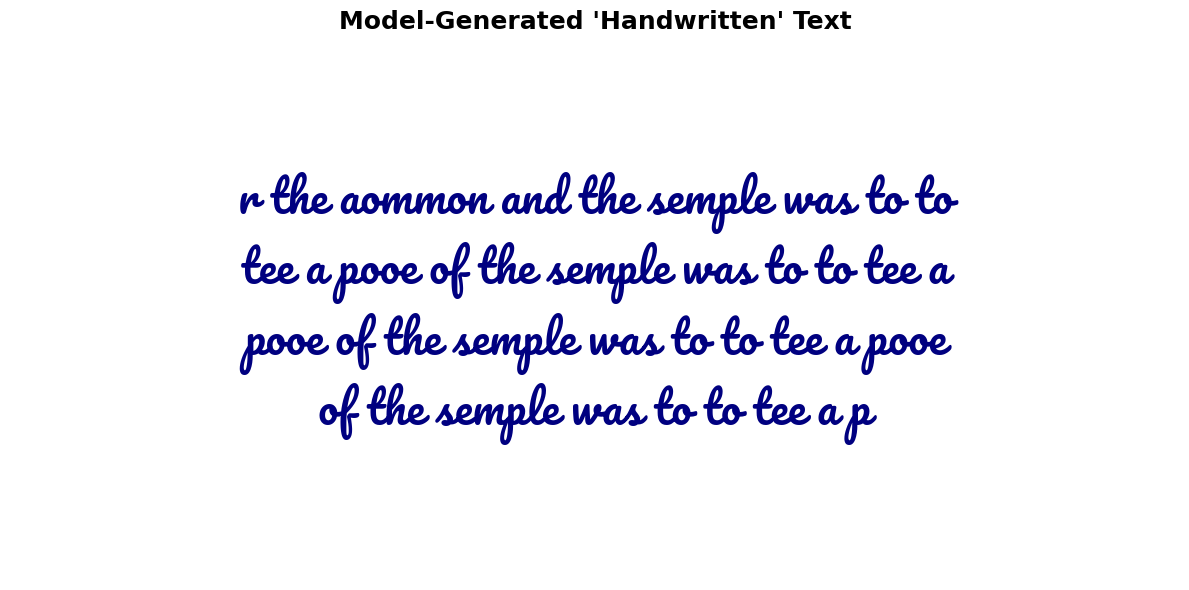

In [ ]:
# Generate and Visualize Handwritten Text (Using fonts)
import sys
import textwrap
import matplotlib.font_manager as fm
import urllib.request
import os
import numpy as np
import matplotlib.pyplot as plt

# downloaded a cursive font (Pacifico) for handwriting-like visualization
font_path = '/content/Pacifico-Regular.ttf'
if not os.path.exists(font_path):
    print("Downloading Pacifico cursive font...")
    # Using the raw.githubusercontent link to bypass GitHub's HTML redirects
    font_url = "https://raw.githubusercontent.com/google/fonts/main/ofl/pacifico/Pacifico-Regular.ttf"
    urllib.request.urlretrieve(font_url, font_path)
    print("Download complete!")

# Registered the font using the absolute path
fm.fontManager.addfont(font_path)
handwriting_font = fm.FontProperties(fname=font_path)

# Picked random starting point to start the generation
start_index = np.random.randint(0, len(dataX) - 1)
pattern = dataX[start_index]
generated_text = ""

print("Model is generating new text based on learned patterns...")

# Asked the Model to generate the next 150 characters
for i in range(150):
    x_input = np.reshape(pattern, (1, len(pattern), 1))
    x_input = x_input / float(vocab_size)

    prediction = model.predict(x_input, verbose=0)
    index = np.argmax(prediction)
    result = int_to_char[index]

    generated_text += result
    pattern.append(index)
    pattern = pattern[1:]

# Print raw output to console to verify
print("\n--- RAW MODEL GENERATED TEXT ---")
print(generated_text)
print("-----------------------------\n")

# Wrap text so it fits in the image
wrapped_text = textwrap.fill(generated_text, width=40)

# Render the visual output using custom font
plt.figure(figsize=(12, 6))

# Use the Pacifico font downloaded
plt.text(0.5, 0.5, wrapped_text, fontsize=32, ha='center', va='center',
         fontproperties=handwriting_font, color='navy')

plt.title("Model-Generated 'Handwritten' Text", fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()